In [5]:
import pandas as pd
df = pd.read_csv('content/Combined_Flights_2022.csv')

In [ ]:
print(df.head())

In [11]:
# 데이터에 어떤 달들이 들어있는지 확인
print(df['Month'].unique())

[ 4.  2.  7.  5.  6.  1.  3. nan]


In [12]:
# 결측치 개수 확인
print(df['Month'].isna().sum())

1


In [ ]:
# Month 컬럼 결측치 제거
df = df.dropna(subset=['Month'])

# 결측치 사라졌는지 확인
print(df['Month'].unique())

[4. 2. 7. 5. 6. 1. 3.]


/tmp/ipykernel_5867/2030136405.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Month', y='Cancelled', data=df, marker='o', ci=None) # ci=None은 속도를 높여줍니다


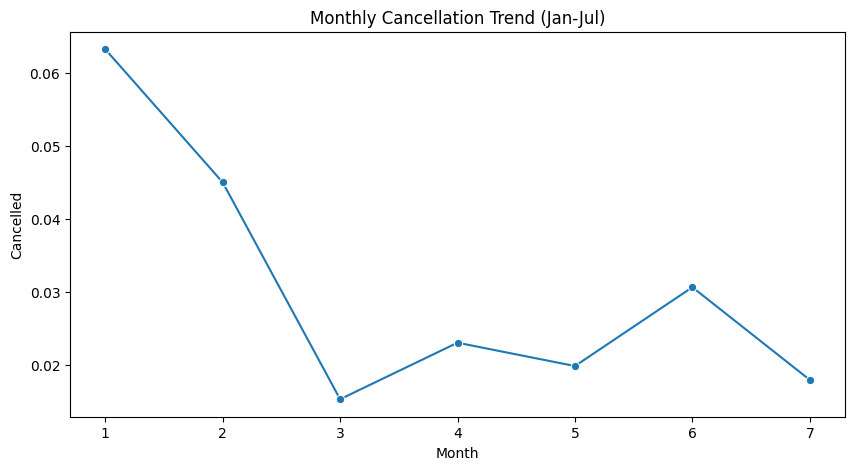

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Month를 정수형으로 변환
df['Month'] = df['Month'].astype(int)

# 2. 그래프 그리기
plt.figure(figsize=(10, 5))
sns.lineplot(x='Month', y='Cancelled', data=df, marker='o', ci=None) # ci=None은 속도 높여주는 역할
plt.title('Monthly Cancellation Trend (Jan-Jul)')
plt.xticks(range(1, 8)) # 1월부터 7월까지만 표시
plt.show()

In [ ]:
print(df['Origin'].unique())

In [24]:
print(df['Origin'].isna().sum())

0


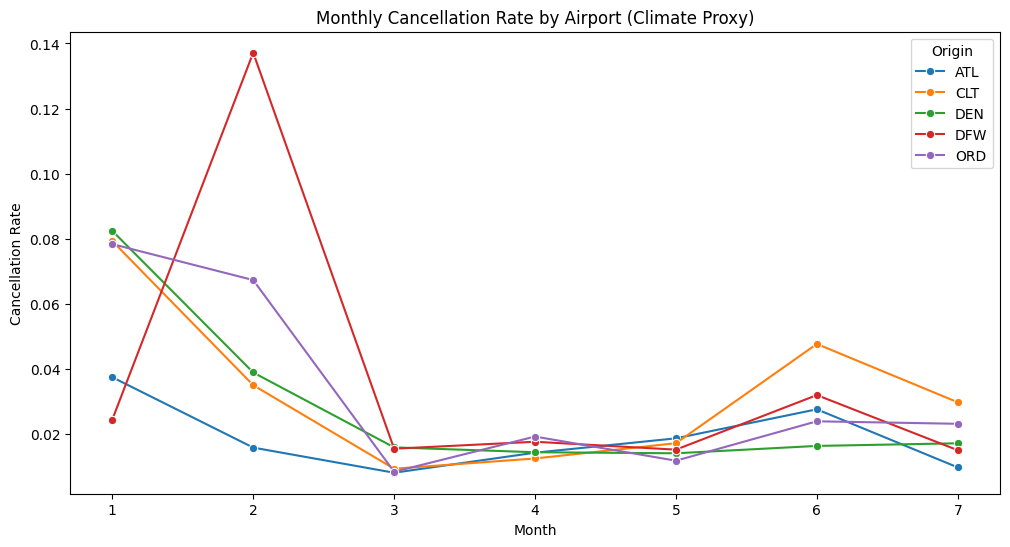

In [18]:
# 1. 출발 공항(Origin)과 월(Month)별 취소율 계산
airport_weather_trend = df.groupby(['Origin', 'Month'])['Cancelled'].mean().reset_index()

# 2. 취소 건수가 많은 주요 공항들만 필터링 (너무 많으면 그래프가 복잡해짐)
# 예: 전체 비행 횟수 상위 5개 공항만 보기
top_airports = df['Origin'].value_counts().head(5).index
subset = airport_weather_trend[airport_weather_trend['Origin'].isin(top_airports)]

# 3. 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.lineplot(data=subset, x='Month', y='Cancelled', hue='Origin', marker='o')
plt.title('Monthly Cancellation Rate by Airport (Climate Proxy)')
plt.ylabel('Cancellation Rate')
plt.show()

In [25]:
print(df['Cancelled'].unique())

[0 1]


In [27]:
print(df['Cancelled'].isna().sum())

0


In [26]:
print(df['Distance'].unique())

[ 212.  295.  251. ... 3724. 2233.  385.]


In [28]:
print(df['Distance'].isna().sum())

0


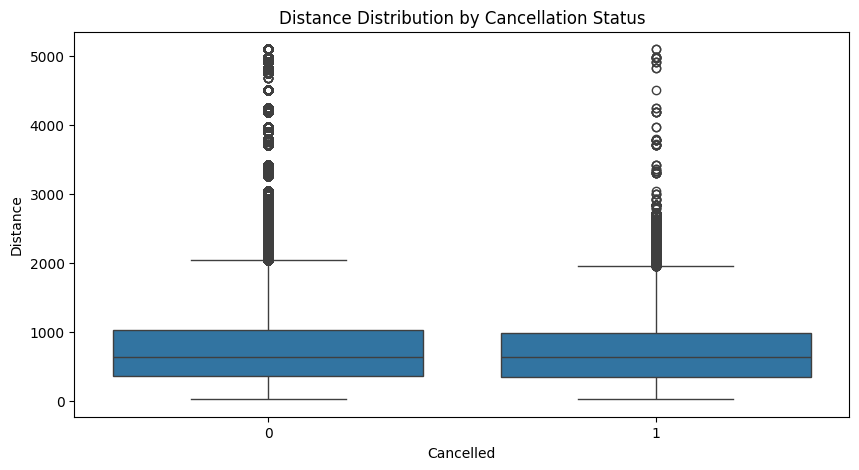

In [29]:
# 비행 거리와 취소의 관계
plt.figure(figsize=(10, 5))
sns.boxplot(x='Cancelled', y='Distance', data=df)
plt.title('Distance Distribution by Cancellation Status')
plt.show()

In [16]:
print(df.groupby('Cancelled')['Distance'].describe())

               count        mean         std   min    25%    50%     75%  \
Cancelled                                                                  
0          3944269.0  799.946828  593.821601  31.0  368.0  644.0  1037.0   
1           122978.0  751.961448  526.625125  31.0  353.0  641.0   994.0   

              max  
Cancelled          
0          5095.0  
1          5095.0  


-- Cancelled 요약 --
Cancelled
0    3944269
1     122978
Name: count, dtype: int64
전체 취소율: 3.02%


/tmp/ipykernel_5867/3205510234.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cancelled', data=df, ax=ax[0], palette='Set2')


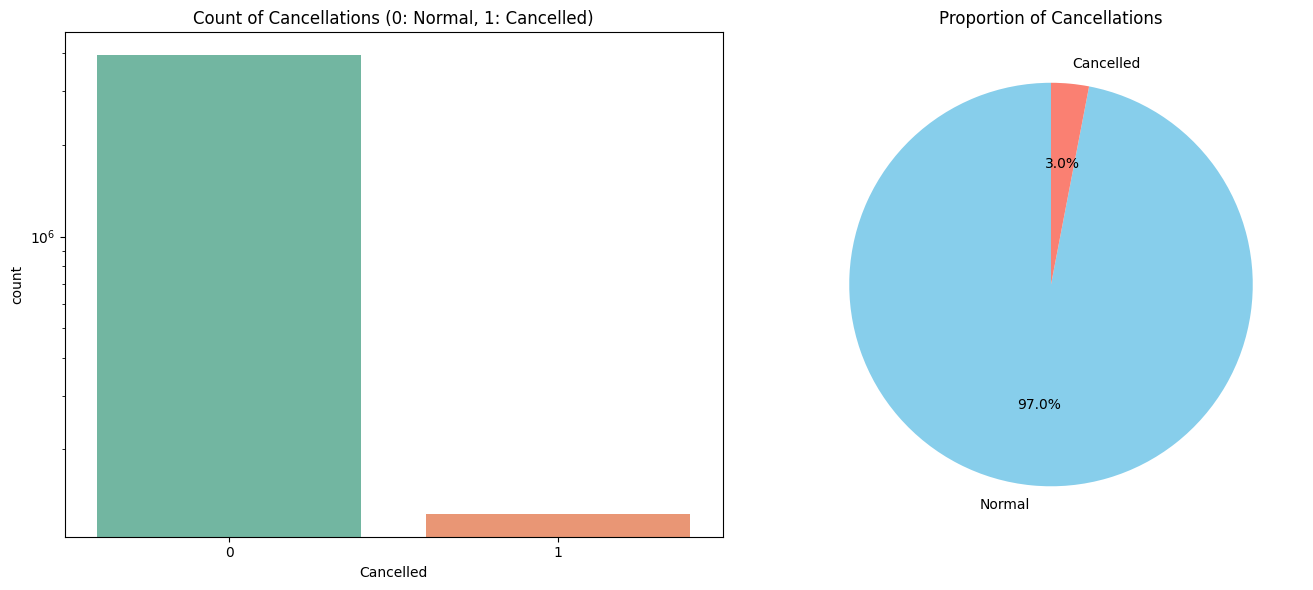

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cancelled 데이터 타입 확인 및 정수형 변환 (True/False인 경우 대비)
df['Cancelled'] = df['Cancelled'].astype(int)

# 2. 요약 통계량 확인
print("-- Cancelled 요약 --")
print(df['Cancelled'].value_counts())
print(f"전체 취소율: {df['Cancelled'].mean() * 100:.2f}%")

# 3. 시각화 (막대 그래프 & 파이 차트)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: 막대 그래프 (개수 차이 체감)
sns.countplot(x='Cancelled', data=df, ax=ax[0], palette='Set2')
ax[0].set_title('Count of Cancellations (0: Normal, 1: Cancelled)')
ax[0].set_yscale('log') # 데이터 차이가 너무 커서 로그 스케일로 설정 (안 하면 1이 안 보일 수 있음)

# 오른쪽: 파이 차트 (비율 체감)
df['Cancelled'].value_counts().plot.pie(
    autopct='%1.1f%%',
    ax=ax[1],
    colors=['skyblue', 'salmon'],
    startangle=90,
    labels=['Normal', 'Cancelled']
)
ax[1].set_title('Proportion of Cancellations')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()